In [ ]:
# =========================================================
# FULL EXPERIMENT
# KHALEEJ DATASET
#
# METHODS:
# - RB-node + CHI2
# - RB-edge + CHI2
# - RB-node-edge + CHI2
# - RB-strength + CHI2
# - RB-PR + CHI2
#
# CLASSIFIERS:
# - Decision Tree
# - Naive Bayes
# - SVM
#
# FEATURE SIZES:
# [100, 500, 1000, 1500, 2000,
#  2500, 3000, 3500, 4000]
#
# VALIDATION:
# - 10 Fold Cross Validation
# =========================================================

# =========================================================
# IMPORTS
# =========================================================
import os
import re
import string
import numpy as np
import pandas as pd
import scipy.sparse as sp
import networkx as nx

from bs4 import BeautifulSoup

from collections import defaultdict
from collections import Counter

from sklearn.model_selection import KFold

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import normalize

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.feature_selection import (
    SelectKBest,
    chi2
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import MultinomialNB

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# DATASET PATH
# =========================================================
DATASET_PATH = (
    r"G:\My Drive\UDINUS\DISERTASI\Proposal Disertasi\1 Draft Paper RQ1 - Fitur Extraction\Inass\data\Khaleej"
)

# =========================================================
# LOAD HTML DATASET
# =========================================================
texts = []
labels = []

for category in os.listdir(DATASET_PATH):

    category_path = os.path.join(
        DATASET_PATH,
        category
    )

    if not os.path.isdir(category_path):
        continue

    for file in os.listdir(category_path):

        if file.endswith(".html"):

            file_path = os.path.join(
                category_path,
                file
            )

            try:

                with open(
                    file_path,
                    "r",
                    encoding="utf-8",
                    errors="ignore"
                ) as f:

                    html = f.read()

                soup = BeautifulSoup(
                    html,
                    "html.parser"
                )

                text = soup.get_text(
                    separator=" "
                )

                texts.append(text)

                labels.append(category)

            except Exception as e:

                print("ERROR:", file_path, e)

print("Total Documents:", len(texts))
print("Total Categories:", len(set(labels)))

# =========================================================
# LABEL ENCODER
# =========================================================
label_encoder = LabelEncoder()

Y = label_encoder.fit_transform(labels)

CLASS_NAMES = label_encoder.classes_

X_texts = np.array(texts)

print("\nClasses:")
print(CLASS_NAMES)

# =========================================================
# FEATURE SIZES
# =========================================================
FEATURE_SIZES = [

    100,
    500,
    1000,
    1500,
    2000,
    2500,
    3000,
    3500,
    4000
]

# =========================================================
# METHODS
# =========================================================
METHODS = [

    "TF-IDF",

    "RB-node",
    "RB-edge",
    "RB-node-edge",
    "RB-strength",
    "RB-PR"
]

# =========================================================
# STOPWORDS
# =========================================================
stopwords = {

    "the", "a", "an", "and", "or",
    "is", "are", "was", "were",
    "to", "of", "in", "on",
    "for", "with", "at", "by",
    "from", "that", "this",
    "it", "as", "be"
}

# =========================================================
# PREPROCESS
# =========================================================
def preprocess(text):

    text = str(text).lower()

    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    text = re.sub(
        r"\d+",
        " ",
        text
    )

    text = text.translate(

        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

# =========================================================
# TOKENIZE
# =========================================================
def tokenize(text):

    tokens = preprocess(text).split()

    tokens = [

        w for w in tokens

        if w not in stopwords
        and len(w) > 1
    ]

    return tokens

# =========================================================
# BUILD RB GRAPH
# =========================================================
def build_rb_graph(texts):

    SUM = defaultdict(float)
    COUNT = defaultdict(int)

    # =====================================================
    # GLOBAL TERM WEIGHT
    # =====================================================
    for text in texts:

        tokens = tokenize(text)

        unique_tokens = set(tokens)

        U = len(unique_tokens)

        if U == 0:
            continue

        bw = 1 / U

        for w in unique_tokens:

            SUM[w] += bw
            COUNT[w] += 1

    AW = {}

    for w in SUM:

        AW[w] = SUM[w] / COUNT[w]

    # =====================================================
    # GRAPH
    # =====================================================
    G = nx.Graph()

    for w in AW:

        G.add_node(w)

    # =====================================================
    # EDGE
    # =====================================================
    for text in texts:

        tokens = tokenize(text)

        for i in range(len(tokens) - 1):

            u = tokens[i]
            v = tokens[i + 1]

            if u == v:
                continue

            edge_weight = (
                AW[u] + AW[v]
            ) / 2

            if G.has_edge(u, v):

                G[u][v]["weight"] += edge_weight

            else:

                G.add_edge(
                    u,
                    v,
                    weight=edge_weight
                )

    # =====================================================
    # NORMALIZE
    # =====================================================
    if G.number_of_edges() > 0:

        max_weight = max(

            data["weight"]

            for _, _, data in G.edges(data=True)
        )

        for u, v, data in G.edges(data=True):

            data["weight"] /= max_weight

    return G

# =========================================================
# COMPUTE RB SCORES
# =========================================================
def compute_rb_scores(G):

    rb_node = dict(G.degree())

    rb_strength = {

        node: sum(

            data["weight"]

            for _, _, data in G.edges(
                node,
                data=True
            )
        )

        for node in G.nodes()
    }

    rb_edge = {}

    for node in G.nodes():

        deg = G.degree(node)

        if deg == 0:

            rb_edge[node] = 0

        else:

            total_weight = sum(

                data["weight"]

                for _, _, data in G.edges(
                    node,
                    data=True
                )
            )

            rb_edge[node] = (
                total_weight / deg
            )

    rb_node_edge = {}

    for node in G.nodes():

        rb_node_edge[node] = (

            rb_node.get(node, 0)
            *
            rb_edge.get(node, 0)
        )

    rb_pr = nx.pagerank(
        G,
        weight='weight'
    )

    score_df = pd.DataFrame({

        "term": list(G.nodes()),

        "RB-node": [
            rb_node.get(w, 0)
            for w in G.nodes()
        ],

        "RB-edge": [
            rb_edge.get(w, 0)
            for w in G.nodes()
        ],

        "RB-node-edge": [
            rb_node_edge.get(w, 0)
            for w in G.nodes()
        ],

        "RB-strength": [
            rb_strength.get(w, 0)
            for w in G.nodes()
        ],

        "RB-PR": [
            rb_pr.get(w, 0)
            for w in G.nodes()
        ]
    })

    return score_df

# =========================================================
# BUILD SPARSE MATRIX
# =========================================================
def build_sparse_matrix(
    texts,
    vocab,
    weights
):

    vocab_idx = {

        w: i
        for i, w in enumerate(vocab)
    }

    rows = []
    cols = []
    data = []

    for i, text in enumerate(texts):

        tokens = tokenize(text)

        counts = Counter(tokens)

        for w, tf in counts.items():

            if w in vocab_idx:

                rows.append(i)

                cols.append(
                    vocab_idx[w]
                )

                data.append(
                    tf * weights[w]
                )

    X = sp.csr_matrix(

        (data, (rows, cols)),

        shape=(
            len(texts),
            len(vocab)
        )
    )

    return X

# =========================================================
# RESULT CONTAINER
# =========================================================
all_results = []

# =========================================================
# CROSS VALIDATION
# =========================================================
kf = KFold(

    n_splits=10,
    shuffle=True,
    random_state=42
)

fold = 1

for train_index, test_index in kf.split(X_texts):

    print("\n================================")
    print("FOLD:", fold)
    print("================================")

    X_train = X_texts[train_index]
    y_train = Y[train_index]

    X_test = X_texts[test_index]
    y_test = Y[test_index]

    # =====================================================
    # BUILD RB GRAPH
    # =====================================================
    G = build_rb_graph(X_train)

    score_df = compute_rb_scores(G)

    # =====================================================
    # METHOD LOOP
    # =====================================================
    for method in METHODS:

        print("\nMETHOD:", method)

        for k in FEATURE_SIZES:

            print("FEATURE SIZE =", k)

            # =================================================
            # TF-IDF
            # =================================================
            if method == "TF-IDF":

                vectorizer = TfidfVectorizer(

                    tokenizer=tokenize,
                    max_features=max(FEATURE_SIZES)
                )

                Xtr = vectorizer.fit_transform(
                    X_train
                )

                Xte = vectorizer.transform(
                    X_test
                )

            # =================================================
            # RB METHODS
            # =================================================
            else:

                sorted_df = score_df.sort_values(

                    by=method,
                    ascending=False
                )

                top_terms = sorted_df.head(

                    max(FEATURE_SIZES)
                )

                vocab = top_terms[
                    "term"
                ].tolist()

                weights = dict(

                    zip(
                        top_terms["term"],
                        top_terms[method]
                    )
                )

                Xtr = build_sparse_matrix(

                    X_train,
                    vocab,
                    weights
                )

                Xte = build_sparse_matrix(

                    X_test,
                    vocab,
                    weights
                )

            # =================================================
            # NORMALIZE
            # =================================================
            Xtr = normalize(Xtr)

            Xte = normalize(Xte)

            # =================================================
            # CHI-SQUARE
            # =================================================
            selector = SelectKBest(

                score_func=chi2,
                k=min(k, Xtr.shape[1])
            )

            Xtr_selected = selector.fit_transform(
                Xtr,
                y_train
            )

            Xte_selected = selector.transform(
                Xte
            )

            # =================================================
            # MODELS
            # =================================================
            models = {

                "DT": DecisionTreeClassifier(
                    random_state=42
                ),

                "NB": MultinomialNB(),

                "SVM": LinearSVC()
            }

            # =================================================
            # TRAIN & EVALUATE
            # =================================================
            for model_name, clf in models.items():

                clf.fit(
                    Xtr_selected,
                    y_train
                )

                y_pred = clf.predict(
                    Xte_selected
                )

                acc = accuracy_score(
                    y_test,
                    y_pred
                )

                prec = precision_score(

                    y_test,
                    y_pred,

                    average='macro',

                    zero_division=0
                )

                rec = recall_score(

                    y_test,
                    y_pred,

                    average='macro',

                    zero_division=0
                )

                f1 = f1_score(

                    y_test,
                    y_pred,

                    average='macro',

                    zero_division=0
                )

                all_results.append({

                    "Fold": fold,

                    "Method": method,

                    "Model": model_name,

                    "Feature_Size": k,

                    "Accuracy": acc,

                    "Precision": prec,

                    "Recall": rec,

                    "F1": f1
                })

                print(

                    f"{model_name} | "

                    f"Acc={acc:.4f} | "

                    f"F1={f1:.4f}"
                )

    fold += 1

# =========================================================
# RESULT DATAFRAME
# =========================================================
df_result = pd.DataFrame(all_results)

df_result = df_result.round(4)

# =========================================================
# SAVE
# =========================================================
df_result.to_csv(

    "Khaleej_RB_CHI2_Results.csv",

    index=False
)

print("\n================================")
print("RESULT SAVED")
print("Khaleej_RB_CHI2_Results.csv")
print("================================")

# =========================================================
# SUMMARY
# =========================================================
summary = (

    df_result
    .groupby(
        [
            "Method",
            "Model",
            "Feature_Size"
        ]
    )[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1"
        ]
    ]
    .mean()
    .reset_index()
)

print("\nSUMMARY")
print(summary)

summary.to_csv(

    "Khaleej_RB_CHI2_Summary.csv",

    index=False
)

Total Documents: 5690
Total Categories: 4

Classes:
['Economy' 'International news' 'Local News' 'Sports']

FOLD: 1

METHOD: TF-IDF
FEATURE SIZE = 100


c:\Users\adesu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


DT | Acc=0.8243 | F1=0.8146
NB | Acc=0.7417 | F1=0.6678
SVM | Acc=0.8594 | F1=0.8466
FEATURE SIZE = 500


c:\Users\adesu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


DT | Acc=0.8541 | F1=0.8499
NB | Acc=0.8805 | F1=0.8636
SVM | Acc=0.9244 | F1=0.9201
FEATURE SIZE = 1000


...

DT | Acc=0.8278 | F1=0.8116
NB | Acc=0.9438 | F1=0.9411
SVM | Acc=0.9613 | F1=0.9581
FEATURE SIZE = 3500


c:\Users\adesu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


DT | Acc=0.8418 | F1=0.8248
NB | Acc=0.9473 | F1=0.9455
SVM | Acc=0.9613 | F1=0.9590
FEATURE SIZE = 4000


c:\Users\adesu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


DT | Acc=0.8436 | F1=0.8294
NB | Acc=0.9473 | F1=0.9455
SVM | Acc=0.9649 | F1=0.9629

METHOD: RB-node
FEATURE SIZE = 100
DT | Acc=0.7926 | F1=0.7775
NB | Acc=0.4323 | F1=0.1509
SVM | Acc=0.6907 | F1=0.5823
FEATURE SIZE = 500
DT | Acc=0.8541 | F1=0.8409
NB | Acc=0.4323 | F1=0.1509
SVM | Acc=0.7381 | F1=0.6490
FEATURE SIZE = 1000
DT | Acc=0.8629 | F1=0.8500
NB | Acc=0.4323 | F1=0.1509
SVM | Acc=0.7504 | F1=0.6646
FEATURE SIZE = 1500
DT | Acc=0.8822 | F1=0.8693
NB | Acc=0.4323 | F1=0.1509
SVM | Acc=0.7487 | F1=0.6627
FEATURE SIZE = 2000
DT | Acc=0.8524 | F1=0.8375
NB | Acc=0.4323 | F1=0.1509
SVM | Acc=0.7487 | F1=0.6627
FEATURE SIZE = 2500
DT | Acc=0.8471 | F1=0.8298
NB | Acc=0.4323 | F1=0.1509
SVM | Acc=0.7487 | F1=0.6627
FEATURE SIZE = 3000
DT | Acc=0.8612 | F1=0.8469
NB | Acc=0.4323 | F1=0.1509
SVM | Acc=0.7504 | F1=0.6646
FEATURE SIZE = 3500
DT | Acc=0.8524 | F1=0.8379
NB | Acc=0.4323 | F1=0.1509
SVM | Acc=0.7504 | F1=0.6646
FEATURE SIZE = 4000
DT | Acc=0.8541 | F1=0.8393
NB | Acc=0.4

In [32]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================
import pandas as pd

# =========================================================
# LOAD CSV FILE
# =========================================================
file_path = r"G:/My Drive/UDINUS/DISERTASI/Proposal Disertasi/1 Draft Paper RQ1 - Fitur Extraction/Inass/Khaleej_RB_CHI2_Summary.csv"

df = pd.read_csv(file_path)

# =========================================================
# CLEAN COLUMN NAMES
# =========================================================
df.columns = df.columns.str.strip()

# =========================================================
# DISPLAY COLUMN NAMES
# =========================================================
print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

# =========================================================
# CHECK REQUIRED COLUMNS
# =========================================================
required_columns = [
    "Method",
    "Model",
    "Feature_Size",
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_columns) > 0:
    print("\nERROR: Missing columns:")
    print(missing_columns)
    exit()

# =========================================================
# CONVERT FEATURE SIZE TO INTEGER
# =========================================================
df["Feature_Size"] = pd.to_numeric(
    df["Feature_Size"],
    errors="coerce"
)

df = df.dropna(subset=["Feature_Size"])

df["Feature_Size"] = df["Feature_Size"].astype(int)

# =========================================================
# CONVERT METRIC COLUMNS TO NUMERIC
# =========================================================
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

for col in metric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# =========================================================
# SORT DATA
# ORDER:
# 1. MODEL
# 2. METHOD
# 3. FEATURE SIZE
# =========================================================
df = df.sort_values(
    by=[
        "Model",
        "Method",
        "Feature_Size"
    ]
)

# =========================================================
# FEATURE SIZE ORDER
# =========================================================
feature_sizes = [
    100,
    500,
    1000,
    1500,
    2000,
    2500,
    3000,
    3500,
    4000
]

# =========================================================
# CREATE ACCURACY TABLE
# =========================================================
acc_table = df.pivot_table(
    index=["Model", "Method"],
    columns="Feature_Size",
    values="Accuracy",
    aggfunc="mean"
)

# =========================================================
# REORDER COLUMNS
# =========================================================
acc_table = acc_table.reindex(
    columns=feature_sizes
)

# =========================================================
# ADD MEAN COLUMN
# =========================================================
acc_table["Mean Accuracy"] = acc_table.mean(axis=1)

# =========================================================
# RESET INDEX
# =========================================================
acc_table = acc_table.reset_index()

# =========================================================
# ROUND VALUES
# =========================================================
acc_table = acc_table.round(4)

# =========================================================
# SORT TABLE
# =========================================================
acc_table = acc_table.sort_values(
    by=["Model", "Method"]
)

# =========================================================
# CREATE F1 TABLE
# =========================================================
f1_table = df.pivot_table(
    index=["Model", "Method"],
    columns="Feature_Size",
    values="F1",
    aggfunc="mean"
)

# =========================================================
# REORDER COLUMNS
# =========================================================
f1_table = f1_table.reindex(
    columns=feature_sizes
)

# =========================================================
# ADD MEAN COLUMN
# =========================================================
f1_table["Mean F1"] = f1_table.mean(axis=1)

# =========================================================
# RESET INDEX
# =========================================================
f1_table = f1_table.reset_index()

# =========================================================
# ROUND VALUES
# =========================================================
f1_table = f1_table.round(4)

# =========================================================
# SORT TABLE
# =========================================================
f1_table = f1_table.sort_values(
    by=["Model", "Method"]
)

# =========================================================
# DISPLAY TABLES
# =========================================================
print("\n=================================================")
print("ACCURACY COMPARISON TABLE")
print("=================================================\n")

print(acc_table)

print("\n=================================================")
print("F1 COMPARISON TABLE")
print("=================================================\n")

print(f1_table)

# =========================================================
# SAVE TO EXCEL
# =========================================================
output_file = "comparison_tables.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    # =====================================================
    # SAVE ACCURACY TABLE
    # =====================================================
    acc_table.to_excel(
        writer,
        sheet_name="Accuracy",
        index=False
    )

    # =====================================================
    # SAVE F1 TABLE
    # =====================================================
    f1_table.to_excel(
        writer,
        sheet_name="F1",
        index=False
    )

# =========================================================
# FINISHED
# =========================================================
print("\n=================================================")
print(f"Tables successfully saved to: {output_file}")
print("=================================================")


=== COLUMN NAMES ===
['Method', 'Model', 'Feature_Size', 'Accuracy', 'Precision', 'Recall', 'F1']

ACCURACY COMPARISON TABLE

Feature_Size Model        Method     100     500    1000    1500    2000  \
0               DT         RB-PR  0.8193  0.8424  0.8478  0.8488  0.8533   
1               DT       RB-edge  0.8399  0.8538  0.8483  0.8522  0.8534   
2               DT       RB-node  0.8292  0.8374  0.8410  0.8430  0.8438   
3               DT  RB-node-edge  0.8174  0.8424  0.8501  0.8487  0.8494   
4               DT   RB-strength  0.8174  0.8424  0.8501  0.8487  0.8494   
5               DT        TF-IDF  0.8299  0.8545  0.8504  0.8513  0.8489   
6               NB         RB-PR  0.4216  0.4216  0.4216  0.4216  0.4216   
7               NB       RB-edge  0.7796  0.8494  0.8541  0.8488  0.8399   
8               NB       RB-node  0.4230  0.4234  0.4223  0.4218  0.4216   
9               NB  RB-node-edge  0.4221  0.4218  0.4216  0.4216  0.4214   
10              NB   RB-strength  0.4

C:\Users\adesu\AppData\Local\Temp\ipykernel_20064\1399055932.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Method", "Model"])["F1"]



MEAN F1 TABLE

Model             DT      NB     SVM
Method                              
TF-IDF        0.8340  0.8984  0.9329
RB-node       0.8273  0.1495  0.6263
RB-edge       0.8394  0.7919  0.9177
RB-node-edge  0.8316  0.1485  0.5213
RB-strength   0.8316  0.1485  0.5213
RB-PR         0.8321  0.1484  0.4950


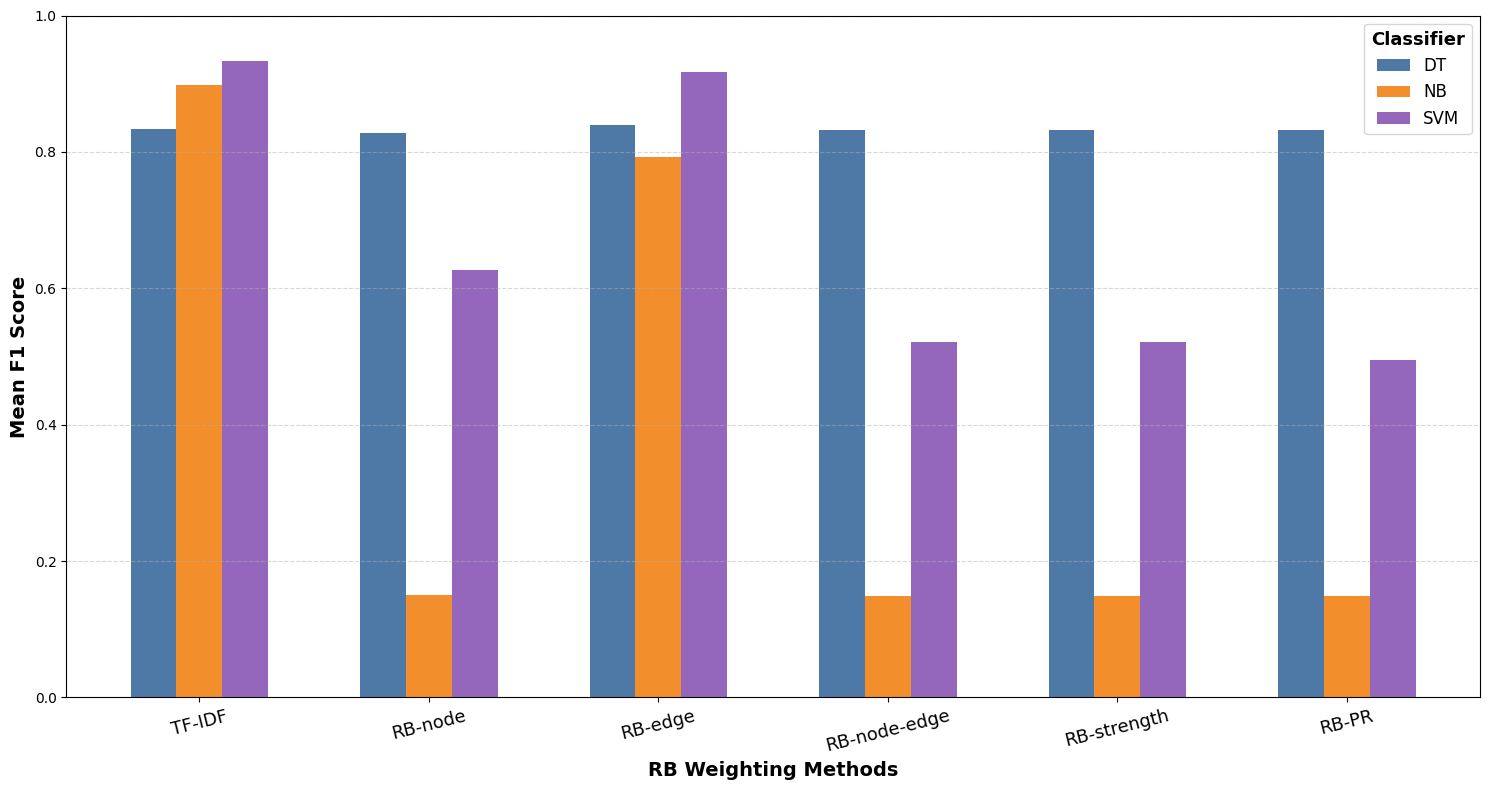


Plot saved as: mean_f1_rb_classifier_barplot.png


In [35]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# LOAD CSV FILE
# =========================================================
file_path = r"G:/My Drive/UDINUS/DISERTASI/Proposal Disertasi/1 Draft Paper RQ1 - Fitur Extraction/Inass/Khaleej_RB_CHI2_Summary.csv"

df = pd.read_csv(file_path)

# =========================================================
# CLEAN COLUMN NAMES
# =========================================================
df.columns = df.columns.str.strip()

# =========================================================
# CHECK REQUIRED COLUMNS
# =========================================================
required_columns = [
    "Method",
    "Model",
    "Feature_Size",
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_columns) > 0:
    print("\nERROR: Missing columns:")
    print(missing_columns)
    exit()

# =========================================================
# CONVERT DATA TYPES
# =========================================================
df["Feature_Size"] = pd.to_numeric(
    df["Feature_Size"],
    errors="coerce"
)

df["F1"] = pd.to_numeric(
    df["F1"],
    errors="coerce"
)

df = df.dropna(
    subset=["Feature_Size", "F1"]
)

df["Feature_Size"] = df["Feature_Size"].astype(int)

# =========================================================
# METHOD ORDER
# =========================================================
method_order = [
    "TF-IDF",
    "RB-node",
    "RB-edge",
    "RB-node-edge",
    "RB-strength",
    "RB-PR"
]

# =========================================================
# MODEL ORDER
# =========================================================
model_order = [
    "DT",
    "NB",
    "SVM"
]

# =========================================================
# APPLY CATEGORICAL ORDER
# =========================================================
df["Method"] = pd.Categorical(
    df["Method"],
    categories=method_order,
    ordered=True
)

df["Model"] = pd.Categorical(
    df["Model"],
    categories=model_order,
    ordered=True
)

# =========================================================
# CALCULATE MEAN F1
# =========================================================
mean_f1 = (
    df.groupby(["Method", "Model"])["F1"]
    .mean()
    .reset_index()
)

# =========================================================
# SORT DATA
# =========================================================
mean_f1 = mean_f1.sort_values(
    by=["Model", "Method"]
)

# =========================================================
# CREATE PIVOT TABLE
# =========================================================
pivot_df = mean_f1.pivot(
    index="Method",
    columns="Model",
    values="F1"
)

# =========================================================
# REORDER
# =========================================================
pivot_df = pivot_df.reindex(method_order)

# =========================================================
# DISPLAY TABLE
# =========================================================
print("\n=================================================")
print("MEAN F1 TABLE")
print("=================================================\n")

print(pivot_df.round(4))

# =========================================================
# DEFINE COLORS
# =========================================================
classifier_colors = {
    "DT": "#4E79A7",
    "NB": "#F28E2B",
    "SVM": "#9467bd"
}

# =========================================================
# GET AXIS DATA
# =========================================================
methods = pivot_df.index.tolist()
models = pivot_df.columns.tolist()

x = np.arange(len(methods))

# =========================================================
# BAR WIDTH
# =========================================================
bar_width = 0.20

# =========================================================
# CREATE FIGURE
# =========================================================
fig, ax = plt.subplots(
    figsize=(15, 8),
    facecolor="white"
)

# =========================================================
# PLOT BARS
# =========================================================
for i, model in enumerate(models):

    color = classifier_colors.get(model, "gray")

    bars = ax.bar(
        x + (i - 1) * bar_width,
        pivot_df[model],
        width=bar_width,
        label=model,
        color=color,
        linewidth=1
    )


# =========================================================
# X LABELS
# =========================================================
ax.set_xticks(x)

ax.set_xticklabels(
    methods,
    rotation=14,
    fontsize=13
)

# =========================================================
# Y LABELS
# =========================================================
ax.set_ylabel(
    "Mean F1 Score",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "RB Weighting Methods",
    fontsize=14,
    fontweight="bold"
)

# =========================================================
# TITLE
# =========================================================
ax.set_title(
    "",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# =========================================================
# GRID
# =========================================================
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# =========================================================
# Y LIMIT
# =========================================================
ax.set_ylim(0, 1.0)

# =========================================================
# LEGEND
# =========================================================
legend = ax.legend(
    title="Classifier",
    fontsize=12,
    title_fontsize=13,
    loc="upper right",
    frameon=True
)

# =========================================================
# MAKE LEGEND BOLD
# =========================================================
legend.get_title().set_fontweight("bold")

# =========================================================
# LAYOUT
# =========================================================
plt.tight_layout()

# =========================================================
# SAVE FIGURE
# =========================================================
plt.savefig(
    "mean_f1_rb_classifier_barplot.png",
    dpi=600,
    bbox_inches="tight"
)

# =========================================================
# SHOW PLOT
# =========================================================
plt.show()

# =========================================================
# FINISHED
# =========================================================
print("\n=================================================")
print("Plot saved as: mean_f1_rb_classifier_barplot.png")
print("=================================================")